# Sensitivity Analysis


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gurobipy as gp
from gurobipy import GRB

BASE = Path('..')
DATA_REAL = BASE / 'data' / 'real'
DATA_SYN = BASE / 'data' / 'synthetic'
RESULTS_DIR = BASE / 'results'
PLOTS_DIR = BASE / 'plots'
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

TIME_LIMIT = 60
MIP_GAP = 0.01

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 220,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})




## Load Data


In [2]:
distance_df = pd.read_csv(DATA_REAL / 'distance_matrix.csv', index_col=0)
time_df = pd.read_csv(DATA_REAL / 'time_matrix.csv', index_col=0)

cafes_df = pd.read_csv(DATA_SYN / 'cafes.csv')
demands_df = pd.read_csv(DATA_SYN / 'demands.csv')
products_df = pd.read_csv(DATA_SYN / 'products.csv')
vans_df = pd.read_csv(DATA_SYN / 'vans.csv')
depot_df = pd.read_csv(DATA_SYN / 'depot.csv')
perish_df = pd.read_csv(DATA_SYN / 'perishability_params.csv')

print('cafes:', cafes_df.shape)
print('products:', products_df.shape)
print('vans:', vans_df.shape)




cafes: (34, 5)
products: (7, 10)
vans: (5, 4)


## Model Function

The function below rebuilds and solves the VRP for one scenario. Each sensitivity experiment only changes one parameter at a time, while the other parameters stay at the baseline setting.


In [3]:
def solve_vrp_scenario(
    scenario_group,
    scenario_name,
    capacity_multiplier=1.0,
    fleet_size=5,
    t_max_override=3.0,
    beta=5.0,
    time_limit=TIME_LIMIT,
    mip_gap=MIP_GAP,
):
    depot_name = depot_df.loc[0, 'name']
    cafes = cafes_df['cafe_name'].tolist()
    nodes = [depot_name] + cafes

    selected_vans = vans_df.head(fleet_size).copy()
    K = selected_vans['van_id'].tolist()
    P = products_df['product_id'].tolist()
    milk_products = products_df.loc[products_df['category'] == 'milk', 'product_id'].tolist()
    A = [(i, j) for i in nodes for j in nodes if i != j]

    demand_raw = {
        (row['cafe_id'], row['product_id']): float(row['daily_demand'])
        for _, row in demands_df.iterrows()
    }
    cafe_id_to_name = dict(zip(cafes_df['cafe_id'], cafes_df['cafe_name']))
    d = {}
    for cafe_id, cafe_name in cafe_id_to_name.items():
        for p in P:
            d[cafe_name, p] = demand_raw.get((cafe_id, p), 0.0)

    w = dict(zip(products_df['product_id'], products_df['weight_per_unit_kg']))
    margin = dict(zip(products_df['product_id'], products_df['margin_per_unit']))

    Q = dict(zip(selected_vans['van_id'], selected_vans['capacity_kg'] * capacity_multiplier))
    F = dict(zip(selected_vans['van_id'], selected_vans['fuel_cost_per_km']))

    D = {(i, j): float(distance_df.loc[i, j]) for i, j in A}
    T = {(i, j): float(time_df.loc[i, j]) / 60.0 for i, j in A}

    perish_params = dict(zip(perish_df['parameter'], perish_df['value']))
    T_max = float(t_max_override)
    loading_time = float(perish_params['loading_time_minutes']) / 60.0
    service_time = float(perish_params['service_time_minutes']) / 60.0
    M_milk = sum(d[i, p] for i in cafes for p in milk_products)
    M_time = 1000

    m = gp.Model(f'sensitivity_{scenario_group}_{scenario_name}')
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = time_limit
    m.Params.MIPGap = mip_gap

    x = m.addVars(A, K, vtype=GRB.BINARY, name='x')
    y = m.addVars(cafes, K, vtype=GRB.BINARY, name='y')
    z = m.addVars(cafes, vtype=GRB.BINARY, name='z')
    q = m.addVars(cafes, P, K, lb=0, vtype=GRB.CONTINUOUS, name='q')
    R = m.addVars(K, lb=0, vtype=GRB.CONTINUOUS, name='R')
    g = m.addVars(K, vtype=GRB.BINARY, name='g')
    u = m.addVars(cafes, K, lb=0, vtype=GRB.CONTINUOUS, name='u')

    product_margin = gp.quicksum(margin[p] * q[i, p, k] for i in cafes for p in P for k in K)
    transport_cost = gp.quicksum(F[k] * D[i, j] * x[i, j, k] for (i, j) in A for k in K)
    route_penalty = gp.quicksum(beta * R[k] for k in K)

    m.setObjective(product_margin - transport_cost - route_penalty, GRB.MAXIMIZE)

    m.addConstrs((gp.quicksum(y[i, k] for k in K) == z[i] for i in cafes), name='serve_once')
    m.addConstrs((gp.quicksum(q[i, p, k] for k in K) == d[i, p] * z[i] for i in cafes for p in P), name='demand_satisfaction')
    m.addConstrs((q[i, p, k] <= d[i, p] * y[i, k] for i in cafes for p in P for k in K), name='delivery_if_served')
    m.addConstrs((gp.quicksum(w[p] * q[i, p, k] for i in cafes for p in P) <= Q[k] for k in K), name='capacity')

    m.addConstrs((gp.quicksum(x[i, j, k] for j in nodes if j != i) == y[i, k] for i in cafes for k in K), name='flow_out')
    m.addConstrs((gp.quicksum(x[j, i, k] for j in nodes if j != i) == y[i, k] for i in cafes for k in K), name='flow_in')
    m.addConstrs((gp.quicksum(x[depot_name, j, k] for j in cafes) <= 1 for k in K), name='depot_departure')
    m.addConstrs((gp.quicksum(x[i, depot_name, k] for i in cafes) <= 1 for k in K), name='depot_return')
    m.addConstrs((gp.quicksum(x[depot_name, j, k] for j in cafes) == gp.quicksum(x[i, depot_name, k] for i in cafes) for k in K), name='depot_balance')

    n_cafes = len(cafes)
    m.addConstrs((u[i, k] - u[j, k] + n_cafes * x[i, j, k] <= n_cafes - 1 for i in cafes for j in cafes if i != j for k in K), name='mtz')
    m.addConstrs((u[i, k] <= n_cafes * y[i, k] for i in cafes for k in K), name='mtz_upper')
    m.addConstrs((u[i, k] >= y[i, k] for i in cafes for k in K), name='mtz_lower')

    m.addConstrs((R[k] == loading_time * gp.quicksum(x[depot_name, j, k] for j in cafes) + gp.quicksum(T[i, j] * x[i, j, k] for (i, j) in A) + service_time * gp.quicksum(y[i, k] for i in cafes) for k in K), name='route_duration')
    m.addConstrs((gp.quicksum(q[i, p, k] for i in cafes for p in milk_products) <= M_milk * g[k] for k in K), name='milk_indicator')
    m.addConstrs((R[k] <= T_max + M_time * (1 - g[k]) for k in K), name='milk_time_limit')

    m.optimize()

    status_map = {
        GRB.OPTIMAL: 'OPTIMAL',
        GRB.TIME_LIMIT: 'TIME_LIMIT',
        GRB.INFEASIBLE: 'INFEASIBLE',
        GRB.UNBOUNDED: 'UNBOUNDED',
        GRB.INF_OR_UNBD: 'INF_OR_UNBD',
    }
    status = status_map.get(m.status, str(m.status))

    result = {
        'scenario_group': scenario_group,
        'scenario_name': scenario_name,
        'capacity_multiplier': capacity_multiplier,
        'fleet_size': fleet_size,
        'T_max': T_max,
        'beta': beta,
        'status': status,
        'objective': np.nan,
        'selected_cafes': 0,
        'vans_used': 0,
        'total_margin': np.nan,
        'transport_cost': np.nan,
        'route_penalty': np.nan,
        'total_route_duration_hr': np.nan,
        'max_route_duration_hr': np.nan,
        'total_load_kg': np.nan,
        'runtime_sec': getattr(m, 'Runtime', np.nan),
        'mip_gap': np.nan,
    }

    if m.SolCount > 0:
        route_durations = [R[k].X for k in K]
        vans_used = [k for k in K if sum(x[depot_name, j, k].X for j in cafes) > 0.5]
        result.update({
            'objective': m.ObjVal,
            'selected_cafes': sum(1 for i in cafes if z[i].X > 0.5),
            'vans_used': len(vans_used),
            'total_margin': product_margin.getValue(),
            'transport_cost': transport_cost.getValue(),
            'route_penalty': route_penalty.getValue(),
            'total_route_duration_hr': sum(route_durations),
            'max_route_duration_hr': max(route_durations) if route_durations else 0,
            'total_load_kg': sum(w[p] * q[i, p, k].X for i in cafes for p in P for k in K),
            'mip_gap': getattr(m, 'MIPGap', np.nan),
        })

    return result




## Define Scenarios

The baseline is:

- capacity multiplier = 1.0
- fleet size = 5 vans
- `T_max = 3` hours
- `beta = 5`

Each sensitivity group changes one parameter while keeping the others fixed.


In [4]:
baseline = {
    'capacity_multiplier': 1.0,
    'fleet_size': 5,
    't_max_override': 3.0,
    'beta': 5.0,
}

scenarios = []

for value in [0.75, 1.0, 1.25, 1.5]:
    s = baseline.copy()
    s['capacity_multiplier'] = value
    scenarios.append(('capacity', f'{value:.2f}x capacity', s))

for value in [2, 3, 4, 5]:
    s = baseline.copy()
    s['fleet_size'] = value
    scenarios.append(('fleet_size', f'{value} vans', s))

for value in [2.0, 3.0, 4.0]:
    s = baseline.copy()
    s['t_max_override'] = value
    scenarios.append(('T_max', f'Tmax {value:.0f}h', s))

for value in [0.0, 2.5, 5.0, 10.0]:
    s = baseline.copy()
    s['beta'] = value
    scenarios.append(('beta', f'beta {value:g}', s))

len(scenarios)




15

## Run Sensitivity Analysis


In [5]:
results = []

for scenario_group, scenario_name, params in scenarios:
    print(f'Running {scenario_group}: {scenario_name}')
    result = solve_vrp_scenario(
        scenario_group=scenario_group,
        scenario_name=scenario_name,
        **params,
    )
    results.append(result)

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_DIR / 'sensitivity_results.csv', index=False)
results_df




Running capacity: 0.75x capacity
Set parameter Username
Set parameter LicenseID to value 2790596
Academic license - for non-commercial use only - expires 2027-03-12
Running capacity: 1.00x capacity
Running capacity: 1.25x capacity
Running capacity: 1.50x capacity
Running fleet_size: 2 vans
Running fleet_size: 3 vans
Running fleet_size: 4 vans
Running fleet_size: 5 vans
Running T_max: Tmax 2h
Running T_max: Tmax 3h
Running T_max: Tmax 4h
Running beta: beta 0
Running beta: beta 2.5
Running beta: beta 5
Running beta: beta 10


,scenario_group,scenario_name,capacity_multiplier,fleet_size,T_max,beta,status,objective,selected_cafes,vans_used,total_margin,transport_cost,route_penalty,total_route_duration_hr,max_route_duration_hr,total_load_kg,runtime_sec,mip_gap
0,capacity,0.75x capacity,0.75,5,3.0,5.0,OPTIMAL,2860.921353,34,3,2926.5,34.903105,30.675542,6.135108,2.119777,1207.73,0.394550,0.009597
1,capacity,1.00x capacity,1.00,5,3.0,5.0,OPTIMAL,2860.729807,34,3,2926.5,35.016160,30.754033,6.150807,2.843638,1207.73,0.309631,0.009751
2,capacity,1.25x capacity,1.25,5,3.0,5.0,OPTIMAL,2862.268832,34,4,2926.5,32.698810,31.532358,6.306472,2.771530,1207.73,0.346195,0.009280
3,capacity,1.50x capacity,1.50,5,3.0,5.0,OPTIMAL,2862.330815,34,3,2926.5,34.128635,30.040550,6.008110,2.749833,1207.73,3.617426,0.008291
4,fleet_size,2 vans,1.00,2,3.0,5.0,OPTIMAL,2824.813313,33,2,2881.3,29.570445,26.916242,5.383248,2.700970,1183.08,0.835915,0.009784
5,fleet_size,3 vans,1.00,3,3.0,5.0,OPTIMAL,2859.774813,34,3,2926.5,36.543095,30.182092,6.036418,2.669333,1207.73,0.239378,0.009599
6,fleet_size,4 vans,1.00,4,3.0,5.0,OPTIMAL,2860.463175,34,3,2926.5,35.829200,30.207625,6.041525,2.871582,1207.73,0.232090,0.009356
7,fleet_size,5 vans,1.00,5,3.0,5.0,OPTIMAL,2860.729807,34,3,2926.5,35.016160,30.754033,6.150807,2.843638,1207.73,0.304929,0.009751
8,T_max,Tmax 2h,1.00,5,2.0,5.0,OPTIMAL,2860.348220,34,4,2926.5,34.697605,31.454175,6.290835,1.923335,1207.73,3.188802,0.008988
9,T_max,Tmax 3h,1.00,5,3.0,5.0,OPTIMAL,2860.729807,34,3,2926.5,35.016160,30.754033,6.150807,2.843638,1207.73,0.297900,0.009751


## Summary Table


In [6]:
summary_cols = [
    'scenario_group',
    'scenario_name',
    'status',
    'objective',
    'selected_cafes',
    'vans_used',
    'transport_cost',
    'route_penalty',
    'max_route_duration_hr',
    'runtime_sec',
]

summary_table = results_df[summary_cols].copy()
summary_table['objective'] = summary_table['objective'].round(2)
summary_table['transport_cost'] = summary_table['transport_cost'].round(2)
summary_table['route_penalty'] = summary_table['route_penalty'].round(2)
summary_table['max_route_duration_hr'] = summary_table['max_route_duration_hr'].round(2)
summary_table['runtime_sec'] = summary_table['runtime_sec'].round(2)
summary_table




,scenario_group,scenario_name,status,objective,selected_cafes,vans_used,transport_cost,route_penalty,max_route_duration_hr,runtime_sec
0,capacity,0.75x capacity,OPTIMAL,2860.92,34,3,34.90,30.68,2.12,0.39
1,capacity,1.00x capacity,OPTIMAL,2860.73,34,3,35.02,30.75,2.84,0.31
2,capacity,1.25x capacity,OPTIMAL,2862.27,34,4,32.70,31.53,2.77,0.35
3,capacity,1.50x capacity,OPTIMAL,2862.33,34,3,34.13,30.04,2.75,3.62
4,fleet_size,2 vans,OPTIMAL,2824.81,33,2,29.57,26.92,2.70,0.84
5,fleet_size,3 vans,OPTIMAL,2859.77,34,3,36.54,30.18,2.67,0.24
6,fleet_size,4 vans,OPTIMAL,2860.46,34,3,35.83,30.21,2.87,0.23
7,fleet_size,5 vans,OPTIMAL,2860.73,34,3,35.02,30.75,2.84,0.30
8,T_max,Tmax 2h,OPTIMAL,2860.35,34,4,34.70,31.45,1.92,3.19
9,T_max,Tmax 3h,OPTIMAL,2860.73,34,3,35.02,30.75,2.84,0.30


## Sensitivity Figures


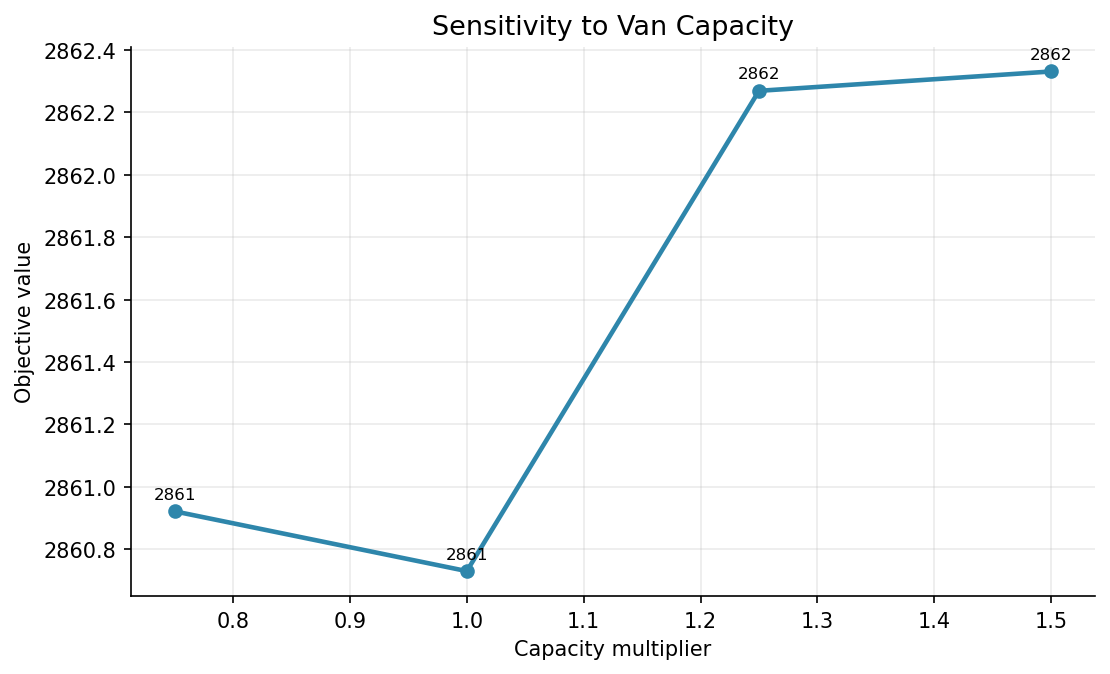

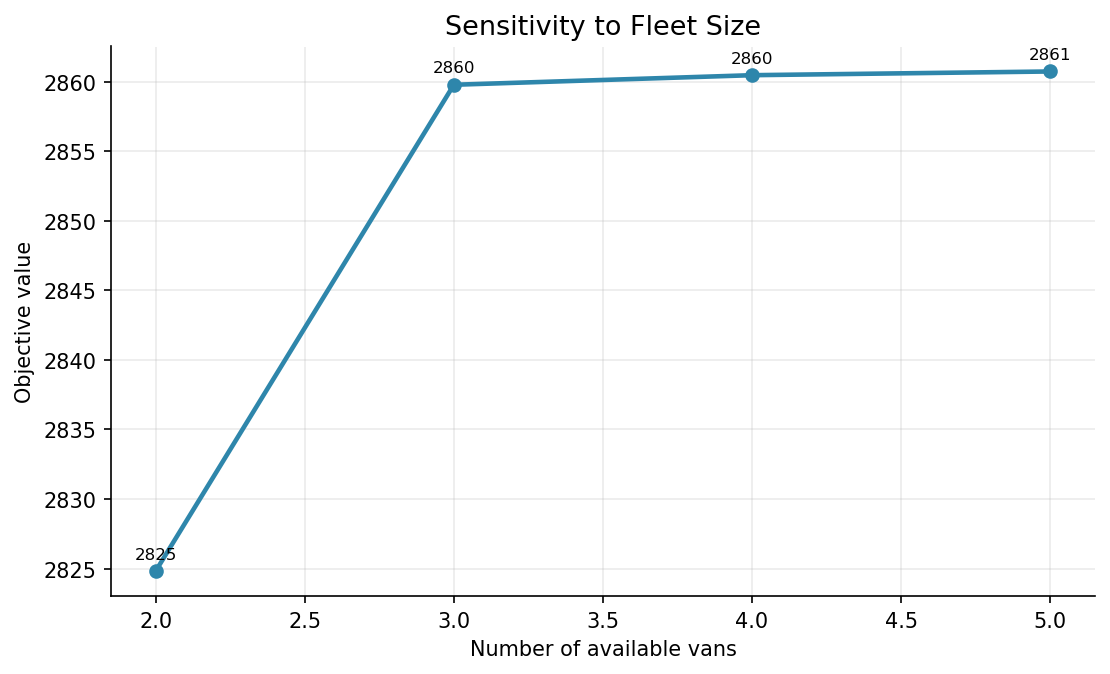

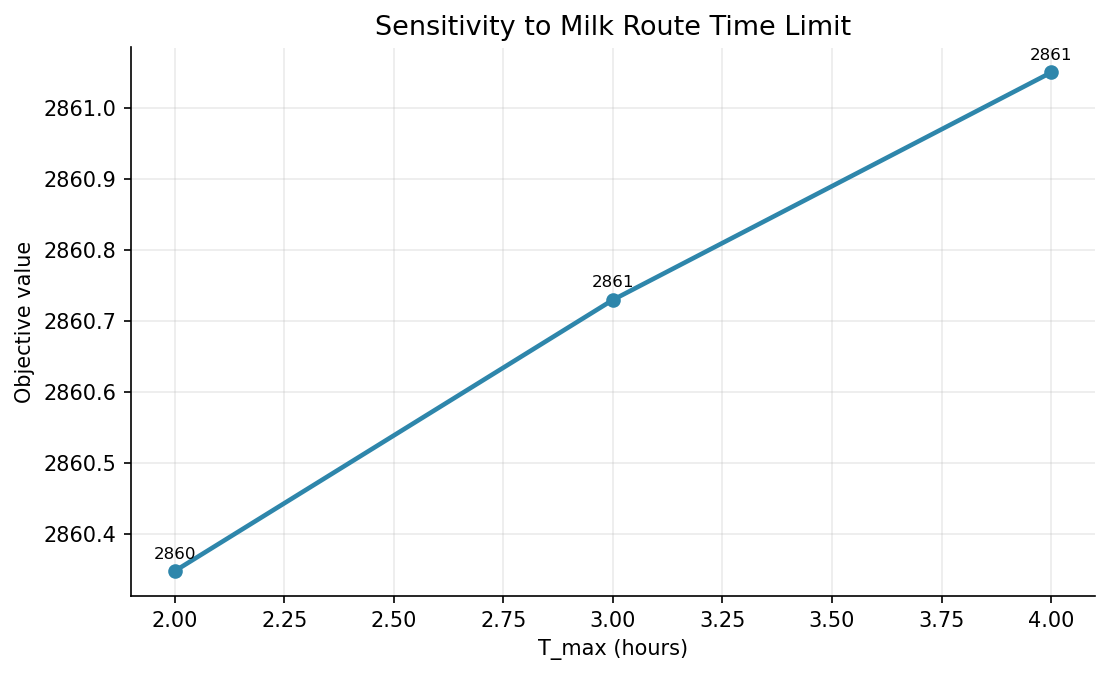

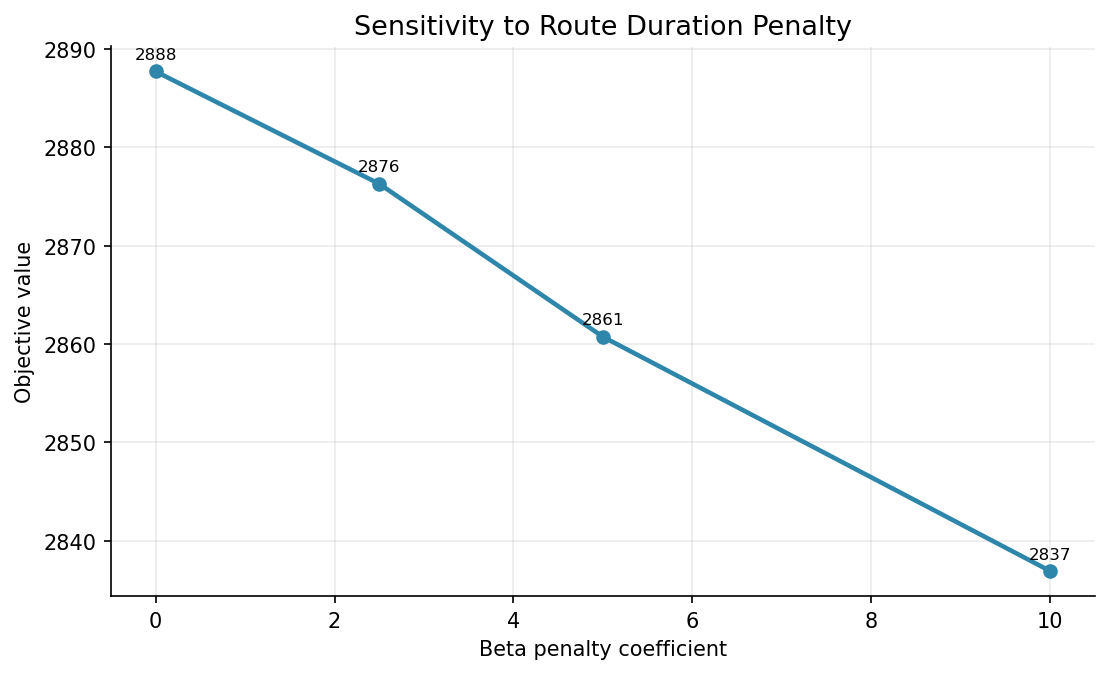

In [7]:
def plot_metric_by_group(results_df, group, x_col, y_col, title, xlabel, ylabel, filename):
    data = results_df[results_df['scenario_group'] == group].copy()
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    ax.plot(data[x_col], data[y_col], marker='o', linewidth=2.2, color='#2E86AB')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    for _, row in data.iterrows():
        ax.annotate(f"{row[y_col]:.0f}", (row[x_col], row[y_col]), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=8)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / filename, bbox_inches='tight')
    plt.show()

plot_metric_by_group(
    results_df,
    group='capacity',
    x_col='capacity_multiplier',
    y_col='objective',
    title='Sensitivity to Van Capacity',
    xlabel='Capacity multiplier',
    ylabel='Objective value',
    filename='08_sensitivity_capacity.png',
)

plot_metric_by_group(
    results_df,
    group='fleet_size',
    x_col='fleet_size',
    y_col='objective',
    title='Sensitivity to Fleet Size',
    xlabel='Number of available vans',
    ylabel='Objective value',
    filename='09_sensitivity_fleet_size.png',
)

plot_metric_by_group(
    results_df,
    group='T_max',
    x_col='T_max',
    y_col='objective',
    title='Sensitivity to Milk Route Time Limit',
    xlabel='T_max (hours)',
    ylabel='Objective value',
    filename='10_sensitivity_tmax.png',
)

plot_metric_by_group(
    results_df,
    group='beta',
    x_col='beta',
    y_col='objective',
    title='Sensitivity to Route Duration Penalty',
    xlabel='Beta penalty coefficient',
    ylabel='Objective value',
    filename='11_sensitivity_beta.png',
)


